## Глобальные цели работы:
- обучить модель линейной регресси на прогнозирование среднего балла студента на основе его режима занятий и сна
- Обучить Logistic Regression для задачи классификации (определить, подвержен ли учащийся риску развития депрессии (столбец Depression), исходя из его образа жизни и уровня стресса)

### План работы:
- Провести разведочный анализ данных (EDA) с использованием визуализации
- Обработать пропуски, дубликаты, выбросы, закодировать нечисленные признаки
- Отобрать релевантные признаки для каждой глобальной цели, возможно получить новые фичи
- Разделить данные на обучающую, валидационную и тестовую выборки без утечки данных
- Реализовать глобальные цели
- Для логистической регрессии доказать отсутствие переобучения
- Оценить качество моделей с использованием соответствующих метрик 
- Сделать выводы о качестве моделей и влиянии этапов предобработки


## Разведочный анализ данных

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("../data/student_lifestyle_100k.csv",sep=",")
df.head()

,Student_ID,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
0,1001,22,Female,Science,3.50,7.3,3.3,3.4,114,5,False
1,1002,20,Male,Engineering,2.72,5.5,7.2,6.0,142,2,False
2,1003,20,Male,Medical,3.01,5.4,2.3,1.8,137,3,False
3,1004,21,Male,Engineering,3.63,8.1,2.0,4.6,130,3,False
4,1005,19,Male,Arts,3.14,6.8,2.6,4.3,4,6,False


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Student_ID          100000 non-null  int64  
 1   Age                 100000 non-null  int64  
 2   Gender              100000 non-null  str    
 3   Department          100000 non-null  str    
 4   CGPA                100000 non-null  float64
 5   Sleep_Duration      100000 non-null  float64
 6   Study_Hours         100000 non-null  float64
 7   Social_Media_Hours  100000 non-null  float64
 8   Physical_Activity   100000 non-null  int64  
 9   Stress_Level        100000 non-null  int64  
 10  Depression          100000 non-null  bool   
dtypes: bool(1), float64(4), int64(4), str(2)
memory usage: 7.7 MB


In [4]:
df.rename(columns={'CGPA':'Academic_score'},inplace=True)
df["Depression"] = df["Depression"].astype(int)
df.head()

,Student_ID,Age,Gender,Department,Academic_score,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
0,1001,22,Female,Science,3.50,7.3,3.3,3.4,114,5,0
1,1002,20,Male,Engineering,2.72,5.5,7.2,6.0,142,2,0
2,1003,20,Male,Medical,3.01,5.4,2.3,1.8,137,3,0
3,1004,21,Male,Engineering,3.63,8.1,2.0,4.6,130,3,0
4,1005,19,Male,Arts,3.14,6.8,2.6,4.3,4,6,0


In [5]:
df.describe()

,Student_ID,Age,Academic_score,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,51000.500000,21.009010,2.898316,6.996425,4.509517,3.503288,74.353180,4.131660,0.100620
std,28867.657797,2.000382,0.532240,1.498682,1.976076,1.486852,43.366963,1.424151,0.300826
min,1001.000000,18.000000,1.560000,3.000000,0.000000,0.000000,0.000000,2.000000,0.000000
25%,26000.750000,19.000000,2.450000,6.000000,3.200000,2.500000,37.000000,3.000000,0.000000
50%,51000.500000,21.000000,2.900000,7.000000,4.500000,3.500000,74.000000,4.000000,0.000000
75%,76000.250000,23.000000,3.350000,8.000000,5.800000,4.500000,112.000000,5.000000,0.000000
max,101000.000000,24.000000,4.000000,12.000000,12.800000,10.000000,149.000000,10.000000,1.000000


#### Удаляем дубликаты:

In [6]:
print("До: ",df.shape)
df.drop_duplicates(inplace=True)
print("После: ",df.shape)

До:  (100000, 11)
После:  (100000, 11)


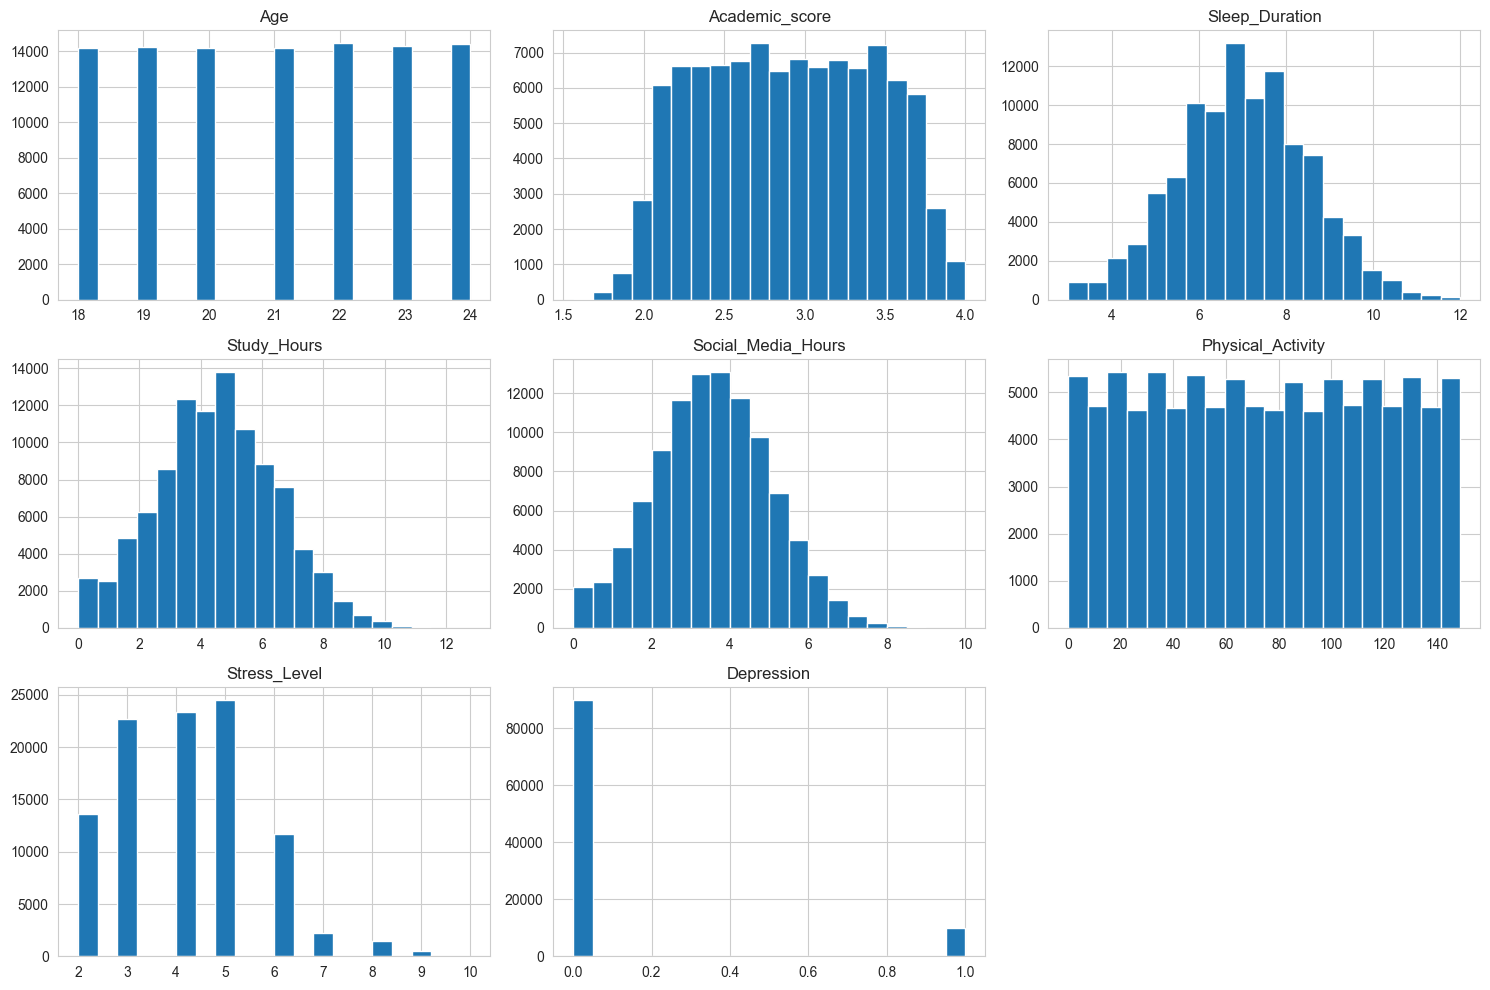

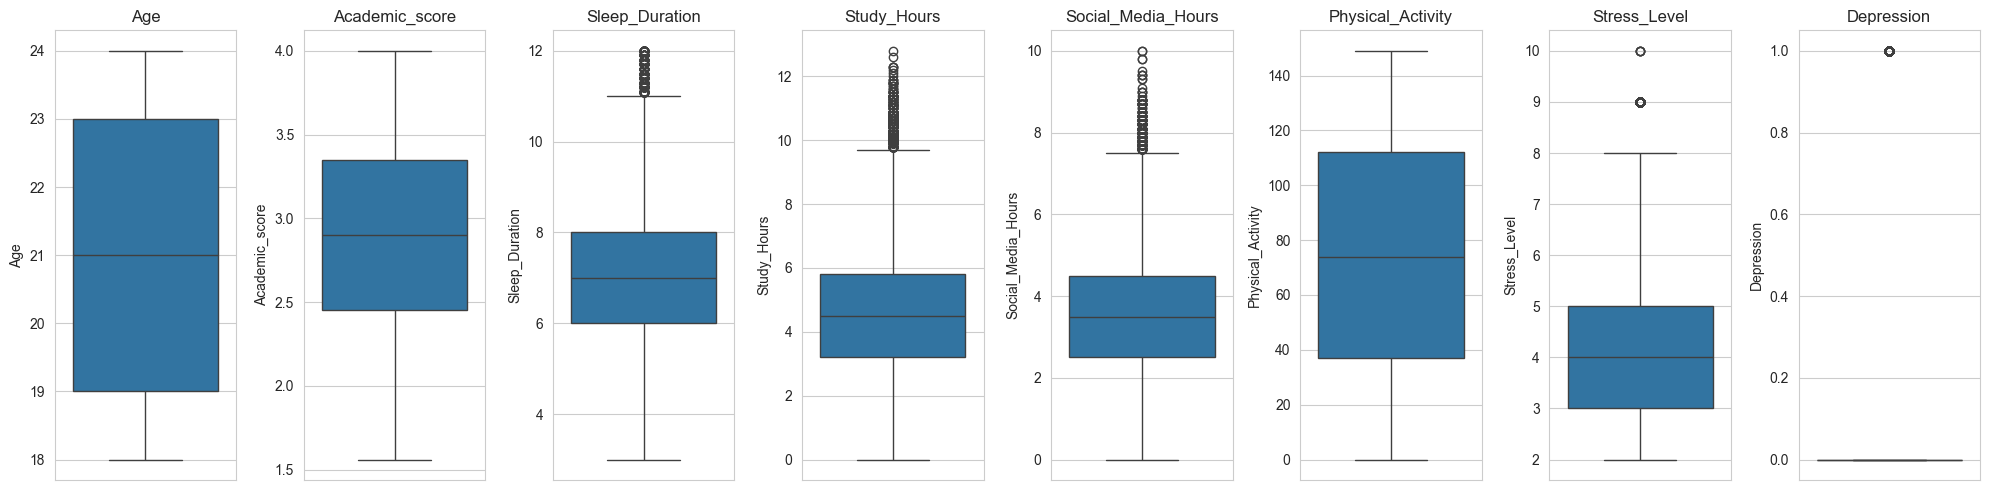

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (9,6)

numeric_cols = df.select_dtypes(include='number').columns.tolist()[1:]# исключаем id студента
# для гистограммы
df[numeric_cols].hist(bins=20,figsize=(15,10))
plt.tight_layout()
plt.show()

# для boxplot
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(20, 5))
for i, column in enumerate(numeric_cols):
    sns.boxplot(data=df, y=column, ax=axes[i]) # Указываем, в какой "квадрат" рисовать
    axes[i].set_title(column)

plt.tight_layout()
plt.show()

#### Результаты разведки:

По гистограммам видно следующее:
- **Age** - распределение практически равномерное от 18 до 24 лет, что логично для студенческой выборки
- **Academic_score (CGPA)** - распределение близко к нормальному с центром около 2.9, что соответствует среднему баллу из `describe()`
- **Sleep_Duration** - нормальное распределение с пиком около 7 часов, есть небольшой правый хвост
- **Study_Hours** - похоже на нормальное, центр около 4.5 часов
- **Social_Media_Hours** - распределение с лёгким правым хвостом, большинство студентов проводят 2-5 часов в соцсетях
- **Physical_Activity** -  распределение с пиками около 0 и 150 минут, что может указывать на две группы: малоподвижных и активных студентов
- **Stress_Level** - ближе к равномерному
- **Depression** - сильный дисбаланс классов: ~90% студентов без депрессии, ~10% — с депрессией

Боксплоты подтверждают наличие выбросов у **Physical_Activity** (значения около 0 и 150), а также у **Stress_Level** и **Sleep_Duration** в верхней части распределения.

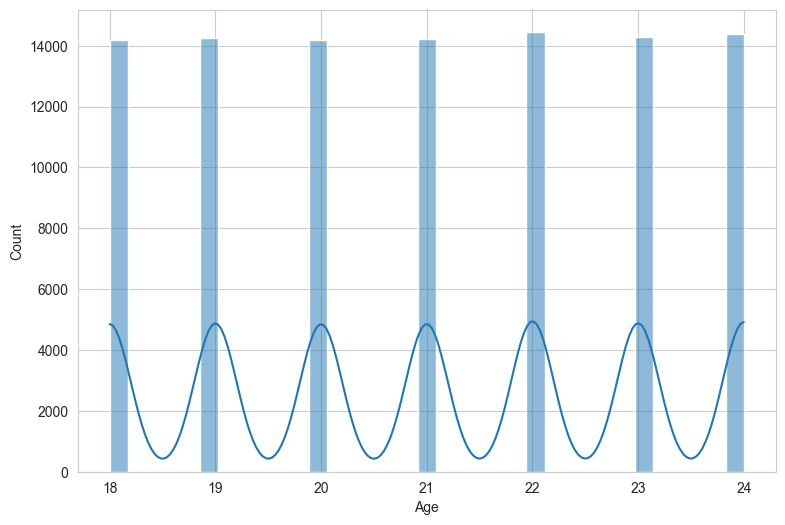

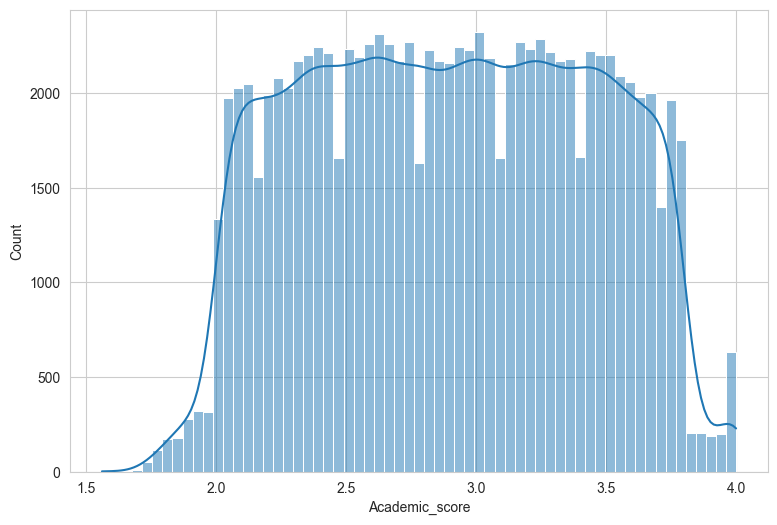

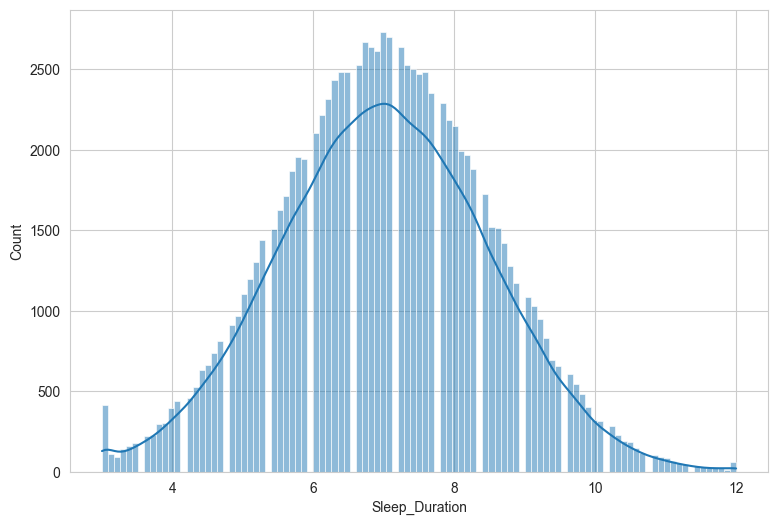

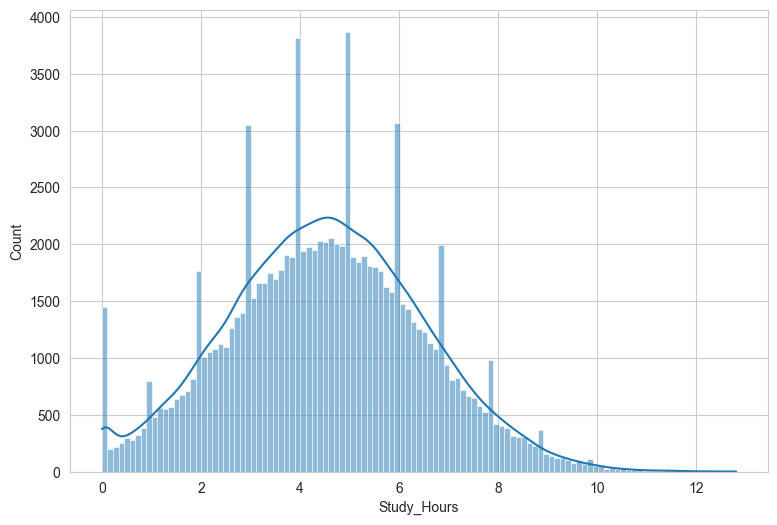

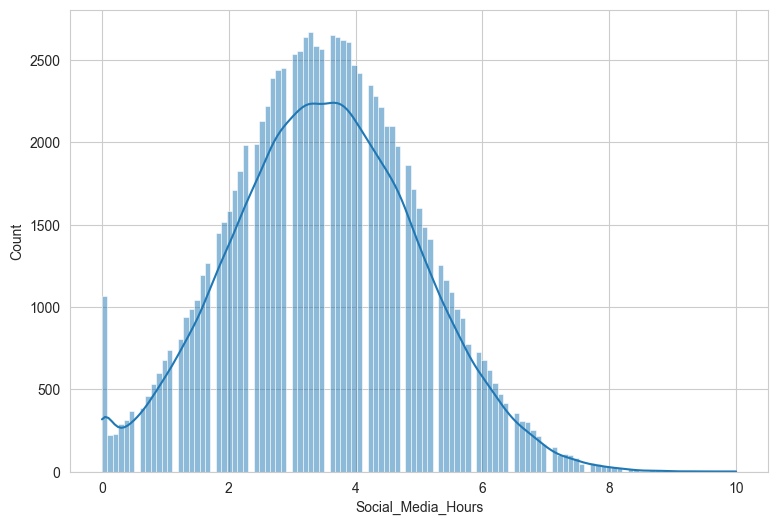

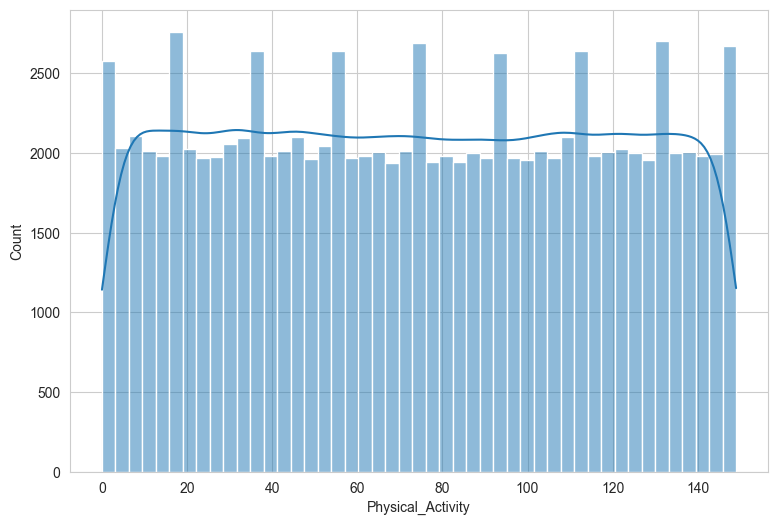

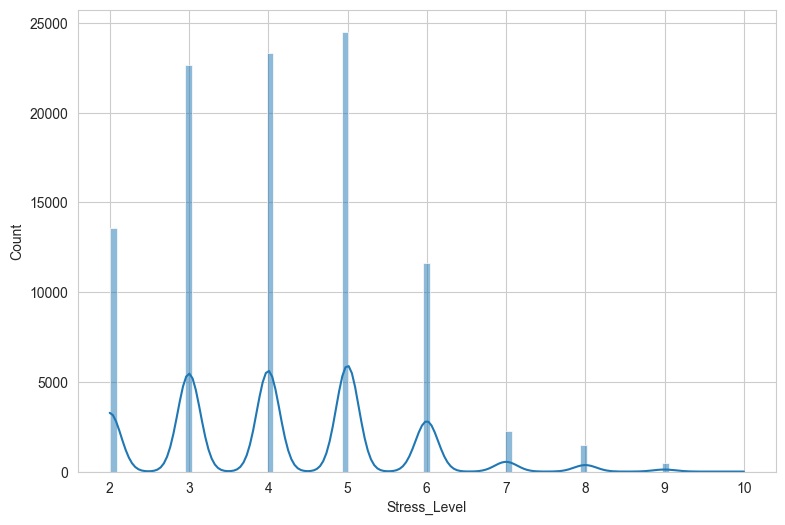

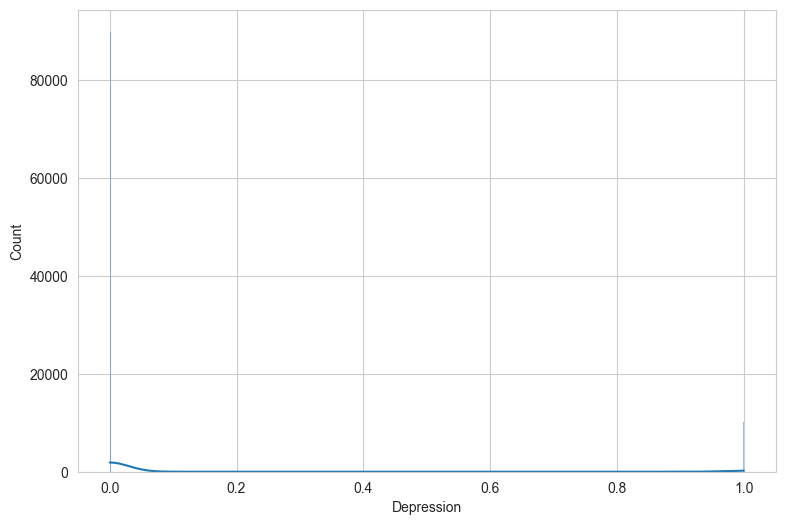

In [8]:
for col in numeric_cols:
    sns.histplot(data=df, x=col,kde=True)
    plt.show()

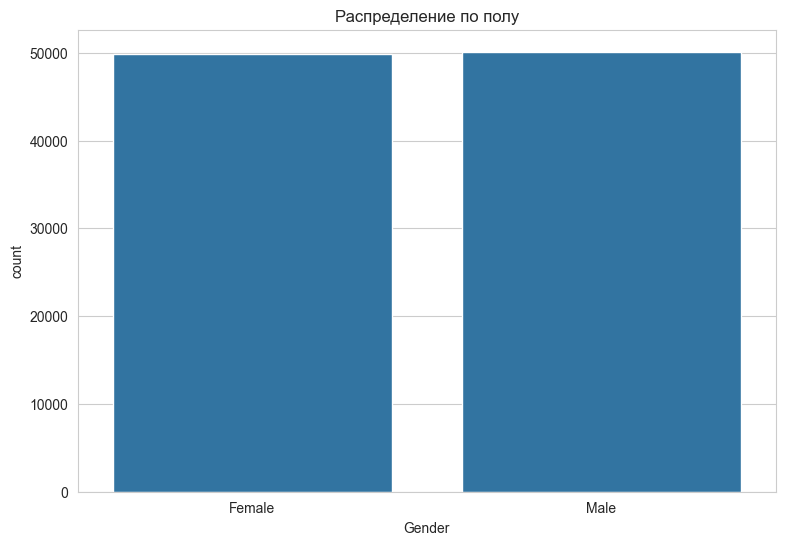

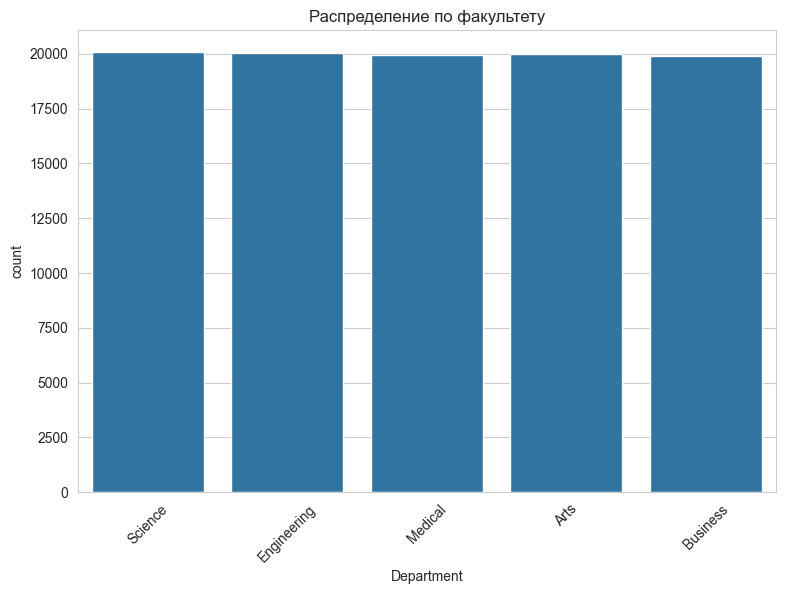

In [9]:
# Пол
sns.countplot(data=df, x='Gender')
plt.title('Распределение по полу')
plt.show()

# Факультет
sns.countplot(data=df, x='Department')
plt.title('Распределение по факультету')
plt.xticks(rotation=45)
plt.show()

### Шаг 2 - обработка данных (дубликаты, пропуски, аномалии)

In [10]:
print("До: ",df.shape)
df.drop_duplicates(inplace=True)
print("После: ",df.shape)

До:  (100000, 11)
После:  (100000, 11)


In [11]:
nulls = df.isna().sum()
print("Кол-во пропусков: ")
print(nulls)

Кол-во пропусков: 
Student_ID            0
Age                   0
Gender                0
Department            0
Academic_score        0
Sleep_Duration        0
Study_Hours           0
Social_Media_Hours    0
Physical_Activity     0
Stress_Level          0
Depression            0
dtype: int64


#### Выбросов у сна нет:

In [12]:
data_low_sleep = df[df["Sleep_Duration"]<=2]
print("Спят не более двух часов :", len(data_low_sleep))
for i in range(9,13):
    data_high_sleep = df[df["Sleep_Duration"]>=i]
    print(f"Спят более или ровно {i} часов: ",len(data_high_sleep))

Спят не более двух часов : 0


Спят более или ровно 9 часов:  9707
Спят более или ровно 10 часов:  2430
Спят более или ровно 11 часов:  451
Спят более или ровно 12 часов:  62


#### Находим людей у которых больше 24 часов в жизни - такие данные не стоит учитывать

In [13]:
data = df.copy()
data['Total_Time'] = data['Sleep_Duration'] + data['Study_Hours'] + data['Social_Media_Hours'] + (data['Physical_Activity'] / 60)


impossible_rows = data[data['Total_Time'] > 24]
print(f"Найдено аномальных строк: {len(impossible_rows)}")

df_cleaned = data[data['Total_Time'] <= 24].copy()


df_cleaned.drop(columns=['Total_Time'], inplace=True)

print(f"Новый размер датасета: {df_cleaned.shape[0]}")

Найдено аномальных строк: 478
Новый размер датасета: 99522


#### Кодируем категориальные признаки:

In [14]:
df_cleaned['Gender'] = df_cleaned['Gender'].apply(lambda gen:1 if gen=="Male" else 0).astype(int)
df_cleaned.rename(columns={"Gender":"Male"},inplace=True)
df_cleaned = pd.get_dummies(df_cleaned, columns=['Department'], drop_first=True)
columns = [i for i in df_cleaned.columns if "Department" in i]
for i in columns:
    df_cleaned[i] = df_cleaned[i].astype(int) 
df_cleaned['Physical_Activity'] = df_cleaned["Physical_Activity"]/60
df_cleaned.head()

,Student_ID,Age,Male,Academic_score,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression,Department_Business,Department_Engineering,Department_Medical,Department_Science
0,1001,22,0,3.50,7.3,3.3,3.4,1.900000,5,0,0,0,0,1
1,1002,20,1,2.72,5.5,7.2,6.0,2.366667,2,0,0,1,0,0
2,1003,20,1,3.01,5.4,2.3,1.8,2.283333,3,0,0,0,1,0
3,1004,21,1,3.63,8.1,2.0,4.6,2.166667,3,0,0,1,0,0
4,1005,19,1,3.14,6.8,2.6,4.3,0.066667,6,0,0,0,0,0


### Строим матрицу корреляций признаков

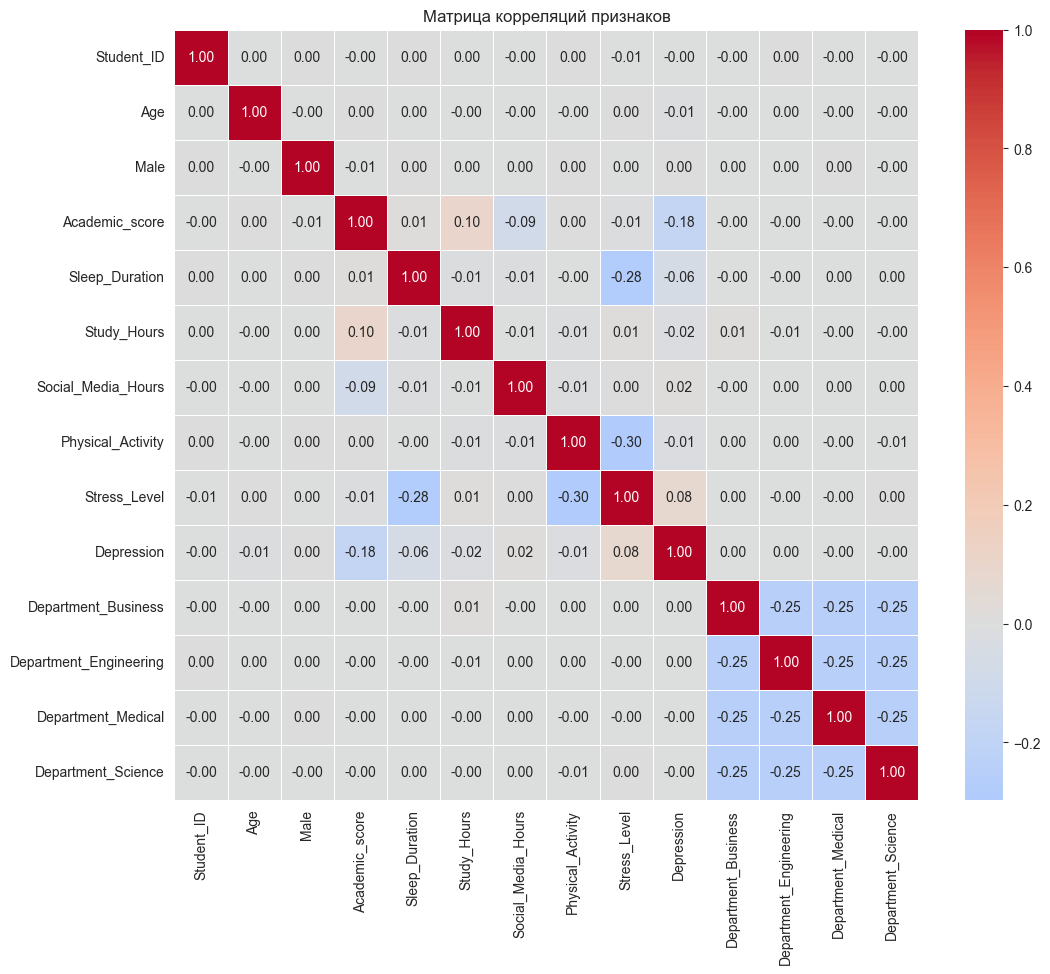

In [15]:
corr_matrix = df_cleaned.corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix,annot=True,
            fmt=".2f",
            cmap='coolwarm',
            center=0,
            linewidths=0.5)
plt.title('Матрица корреляций признаков')
plt.show()

### Шаг 3 - отбираем релевантные признаки для обучения модели лин регр
__Замечание__:
сформируем 2 датесета - в первом будут все данные кроме Student_ID, а во втором - исключим пол, возраст и депортаменты

на основе метрик качеств сделаем соотв. выводы

In [16]:
data_1 = df_cleaned.copy()
y_target = df_cleaned["Academic_score"]
data_1.drop(columns=["Student_ID","Academic_score","Depression"],inplace=True)
data_1.head()

,Age,Male,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Department_Business,Department_Engineering,Department_Medical,Department_Science
0,22,0,7.3,3.3,3.4,1.900000,5,0,0,0,1
1,20,1,5.5,7.2,6.0,2.366667,2,0,1,0,0
2,20,1,5.4,2.3,1.8,2.283333,3,0,0,1,0
3,21,1,8.1,2.0,4.6,2.166667,3,0,1,0,0
4,19,1,6.8,2.6,4.3,0.066667,6,0,0,0,0


In [17]:
data_2 = df_cleaned.copy()
data_2.drop(columns=["Student_ID","Age","Depression","Male","Academic_score","Department_Business","Department_Engineering","Department_Medical","Department_Science"],inplace=True)
data_2.head()

,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level
0,7.3,3.3,3.4,1.900000,5
1,5.5,7.2,6.0,2.366667,2
2,5.4,2.3,1.8,2.283333,3
3,8.1,2.0,4.6,2.166667,3
4,6.8,2.6,4.3,0.066667,6


In [18]:
data_3 = df_cleaned.copy()
data_3.drop(columns=["Student_ID","Academic_score"],inplace=True)
data_3["Deviation_from_norm_sleep"] = (data_3["Sleep_Duration"] - data_3["Sleep_Duration"].mean()).abs()
data_3["Deviation_from_norm_study"] = (data_3["Study_Hours"] - data_3["Study_Hours"].mean()).abs()
data_3["Study_Sleep_Interaction"] = data_3["Sleep_Duration"] * data_3["Study_Hours"]
data_3["Study_Social_Interaction"] = data_3["Study_Hours"] * data_3["Social_Media_Hours"]
data_3.drop(columns=["Sleep_Duration","Study_Hours","Depression"],inplace=True)
data_3.head()

,Age,Male,Social_Media_Hours,Physical_Activity,Stress_Level,Department_Business,Department_Engineering,Department_Medical,Department_Science,Deviation_from_norm_sleep,Deviation_from_norm_study,Study_Sleep_Interaction,Study_Social_Interaction
0,22,0,3.4,1.900000,5,0,0,0,1,0.314148,1.191645,24.09,11.22
1,20,1,6.0,2.366667,2,0,1,0,0,1.485852,2.708355,39.60,43.20
2,20,1,1.8,2.283333,3,0,0,1,0,1.585852,2.191645,12.42,4.14
3,21,1,4.6,2.166667,3,0,1,0,0,1.114148,2.491645,16.20,9.20
4,19,1,4.3,0.066667,6,0,0,0,0,0.185852,1.891645,17.68,11.18


### Обучение модели на датасете 1

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler

X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(data_1, y_target, test_size=0.2, random_state=42)
X_valid_1, X_test_1, y_valid_1, y_test_1 = train_test_split(X_test_1, y_test_1, test_size=0.5, random_state=42)

scaler_1 = StandardScaler()

X_train_scaled_1 = scaler_1.fit_transform(X_train_1)
X_valid_scaled_1 = scaler_1.transform(X_valid_1)
X_test_scaled_1 = scaler_1.transform(X_test_1)

model_1 = LinearRegression()
model_1.fit(X_train_scaled_1, y_train_1)

y_pred_1 = model_1.predict(X_train_scaled_1)
y_pred_valid_1 = model_1.predict(X_valid_scaled_1)
y_pred_test_1 = model_1.predict(X_test_scaled_1)


def evaluate_model(y_true, y_pred, dataset_name="Dataset", split_name="Train"):
    """Расчет и вывод метрик качества"""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100

    print(f"\n📊 Метрики для {dataset_name} на выборке {split_name}:")
    print(f"  MAE:  {mae:,.2f}")
    print(f"  RMSE: {rmse:,.2f}")
    print(f"  R²:   {r2:.4f}")
    print(f"  MAPE: {mape:.2f}%")

    return {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE': mape}

print(evaluate_model(y_train_1,y_pred_1, "Dataset1", "Train"))
print(evaluate_model(y_valid_1,y_pred_valid_1, "Dataset1", "Validation"))
print(evaluate_model(y_test_1,y_pred_test_1, "Dataset1", "Test"))


📊 Метрики для Dataset1 на выборке Train:
  MAE:  0.45
  RMSE: 0.53
  R²:   0.0178
  MAPE: 16.52%
{'MAE': 0.4538675894922201, 'RMSE': np.float64(0.5270260930171915), 'R2': 0.017845160273901373, 'MAPE': 16.52150417379573}

📊 Метрики для Dataset1 на выборке Validation:
  MAE:  0.46
  RMSE: 0.53
  R²:   0.0155
  MAPE: 16.75%
{'MAE': 0.45953484027991415, 'RMSE': np.float64(0.5305230092907708), 'R2': 0.015546160047405166, 'MAPE': 16.751363083088915}

📊 Метрики для Dataset1 на выборке Test:
  MAE:  0.45
  RMSE: 0.53
  R²:   0.0198
  MAPE: 16.61%
{'MAE': 0.4540541272790399, 'RMSE': np.float64(0.5265367340686726), 'R2': 0.019829375548119477, 'MAPE': 16.605760388596728}


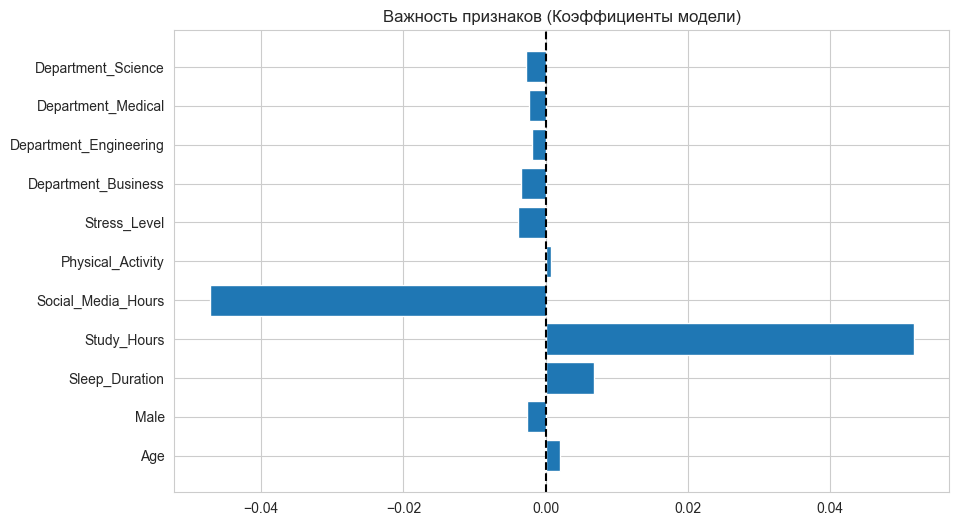

In [20]:
import matplotlib.pyplot as plt


features = X_train_1.columns 
coefs = model_1.coef_

plt.figure(figsize=(10, 6))
plt.barh(features, coefs)
plt.axvline(x=0, color='black', linestyle='--')
plt.title('Важность признаков (Коэффициенты модели)')
plt.show()

### Обучение модели на датасете 2

In [21]:
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(data_2, y_target, test_size=0.2, random_state=42)
X_valid_2, X_test_2, y_valid_2, y_test_2 = train_test_split(X_test_2, y_test_2, test_size=0.5, random_state=42)

scaler_2 = StandardScaler()

X_train_scaled_2 = scaler_2.fit_transform(X_train_2)
X_valid_scaled_2 = scaler_2.transform(X_valid_2)
X_test_scaled_2 = scaler_2.transform(X_test_2)

model_2 = LinearRegression()
model_2.fit(X_train_scaled_2, y_train_2)

y_pred_2 = model_2.predict(X_train_scaled_2)
y_pred_valid_2 = model_2.predict(X_valid_scaled_2)
y_pred_test_2 = model_2.predict(X_test_scaled_2)


print(evaluate_model(y_train_2,y_pred_2, "Dataset2", "Train"))
print(evaluate_model(y_valid_2,y_pred_valid_2, "Dataset2", "Validation"))
print(evaluate_model(y_test_2,y_pred_test_2, "Dataset2", "Test"))


📊 Метрики для Dataset2 на выборке Train:
  MAE:  0.45
  RMSE: 0.53
  R²:   0.0178
  MAPE: 16.52%
{'MAE': 0.45388380987272586, 'RMSE': np.float64(0.5270449673900102), 'R2': 0.0177748112388203, 'MAPE': 16.52203974286705}

📊 Метрики для Dataset2 на выборке Validation:
  MAE:  0.46
  RMSE: 0.53
  R²:   0.0156
  MAPE: 16.75%
{'MAE': 0.45951301874220785, 'RMSE': np.float64(0.5304976769217199), 'R2': 0.015640172756166804, 'MAPE': 16.750913459274045}

📊 Метрики для Dataset2 на выборке Test:
  MAE:  0.45
  RMSE: 0.53
  R²:   0.0197
  MAPE: 16.61%
{'MAE': 0.4540897404018483, 'RMSE': np.float64(0.5265592509539033), 'R2': 0.019745541468027206, 'MAPE': 16.60762272273746}


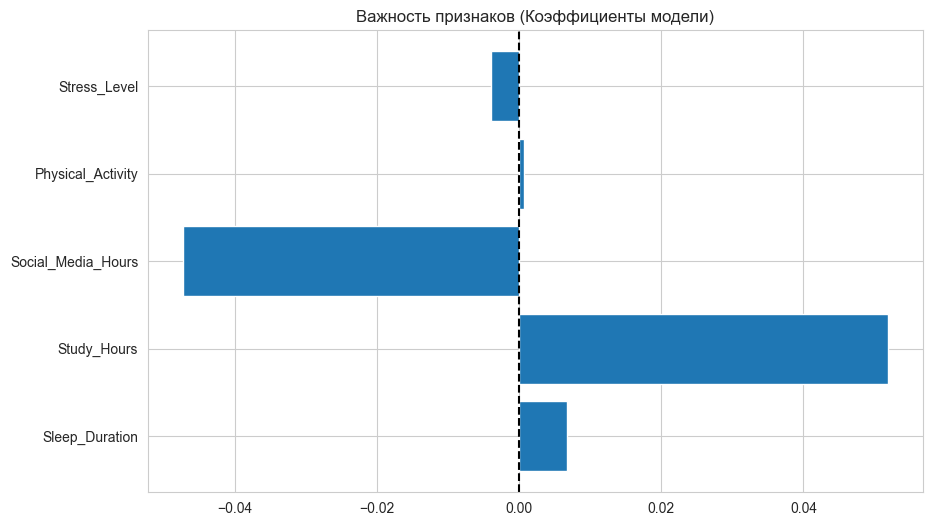

In [22]:
import matplotlib.pyplot as plt


features = X_train_2.columns 
coefs = model_2.coef_

plt.figure(figsize=(10, 6))
plt.barh(features, coefs)
plt.axvline(x=0, color='black', linestyle='--')
plt.title('Важность признаков (Коэффициенты модели)')
plt.show()

### Обучение модели на датасете 3

In [23]:
X_train_3, X_test_3, y_train_3, y_test_3 = train_test_split(data_3, y_target, test_size=0.2, random_state=42)
X_valid_3, X_test_3, y_valid_3, y_test_3 = train_test_split(X_test_3, y_test_3, test_size=0.5, random_state=42)

scaler_3 = StandardScaler()

X_train_scaled_3 = scaler_3.fit_transform(X_train_3)
X_valid_scaled_3 = scaler_3.transform(X_valid_3)
X_test_scaled_3 = scaler_3.transform(X_test_3)

model_3 = LinearRegression()
model_3.fit(X_train_scaled_3, y_train_3)

y_pred_3 = model_3.predict(X_train_scaled_3)
y_pred_valid_3 = model_3.predict(X_valid_scaled_3)
y_pred_test_3 = model_3.predict(X_test_scaled_3)


print(evaluate_model(y_train_3,y_pred_3, "Dataset3", "Train"))
print(evaluate_model(y_valid_3,y_pred_valid_3, "Dataset3", "Validation"))
print(evaluate_model(y_test_3,y_pred_test_3, "Dataset3", "Test"))
print(model_3.coef_)
print(model_3.intercept_)


📊 Метрики для Dataset3 на выборке Train:
  MAE:  0.45
  RMSE: 0.53
  R²:   0.0250
  MAPE: 16.47%
{'MAE': 0.4526041729465772, 'RMSE': np.float64(0.5251038224942556), 'R2': 0.02499670075488103, 'MAPE': 16.472212388990908}

📊 Метрики для Dataset3 на выборке Validation:
  MAE:  0.46
  RMSE: 0.53
  R²:   0.0222
  MAPE: 16.70%
{'MAE': 0.4583599651021173, 'RMSE': np.float64(0.5287245276628252), 'R2': 0.02220947554675845, 'MAPE': 16.699634620629258}

📊 Метрики для Dataset3 на выборке Test:
  MAE:  0.45
  RMSE: 0.53
  R²:   0.0242
  MAPE: 16.57%
{'MAE': 0.45315615850161695, 'RMSE': np.float64(0.5253515779310135), 'R2': 0.02423684723842856, 'MAPE': 16.568565539991344}
[ 0.00180664 -0.00273094 -0.06695079  0.0019387  -0.0003251  -0.00345921
 -0.00203027 -0.00214938 -0.00240262 -0.00803334  0.04622632  0.03024228
  0.03017102]
2.898957885878644


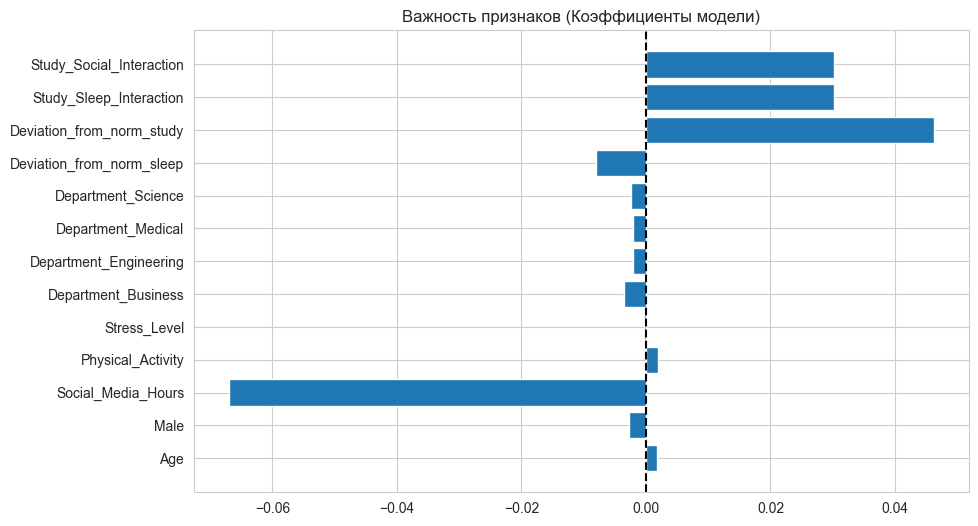

In [24]:
import matplotlib.pyplot as plt


features = X_train_3.columns 
coefs = model_3.coef_

plt.figure(figsize=(10, 6))
plt.barh(features, coefs)
plt.axvline(x=0, color='black', linestyle='--')
plt.title('Важность признаков (Коэффициенты модели)')
plt.show()

#### Добавляем эпохи


📊 Метрики для Dataset на выборке Epoch 0:
  MAE:  0.45
  RMSE: 0.53
  R²:   0.0218
  MAPE: 16.51%

📊 Метрики для Dataset на выборке Epoch 1:
  MAE:  0.45
  RMSE: 0.53
  R²:   0.0202
  MAPE: 16.47%

📊 Метрики для Dataset на выборке Epoch 2:
  MAE:  0.45
  RMSE: 0.53
  R²:   0.0230
  MAPE: 16.48%

📊 Метрики для Dataset на выборке Epoch 3:
  MAE:  0.45
  RMSE: 0.53
  R²:   0.0217
  MAPE: 16.50%

📊 Метрики для Dataset на выборке Epoch 4:
  MAE:  0.45
  RMSE: 0.53
  R²:   0.0228
  MAPE: 16.49%

📊 Метрики для Dataset на выборке Epoch 5:
  MAE:  0.45
  RMSE: 0.53
  R²:   0.0229
  MAPE: 16.48%

📊 Метрики для Dataset на выборке Epoch 6:
  MAE:  0.45
  RMSE: 0.53
  R²:   0.0206
  MAPE: 16.50%

📊 Метрики для Dataset на выборке Epoch 7:
  MAE:  0.45
  RMSE: 0.53
  R²:   0.0229
  MAPE: 16.44%

📊 Метрики для Dataset на выборке Epoch 8:
  MAE:  0.45
  RMSE: 0.53
  R²:   0.0225
  MAPE: 16.46%

📊 Метрики для Dataset на выборке Epoch 9:
  MAE:  0.45
  RMSE: 0.53
  R²:   0.0236
  MAPE: 16.46%

📊 Метрики

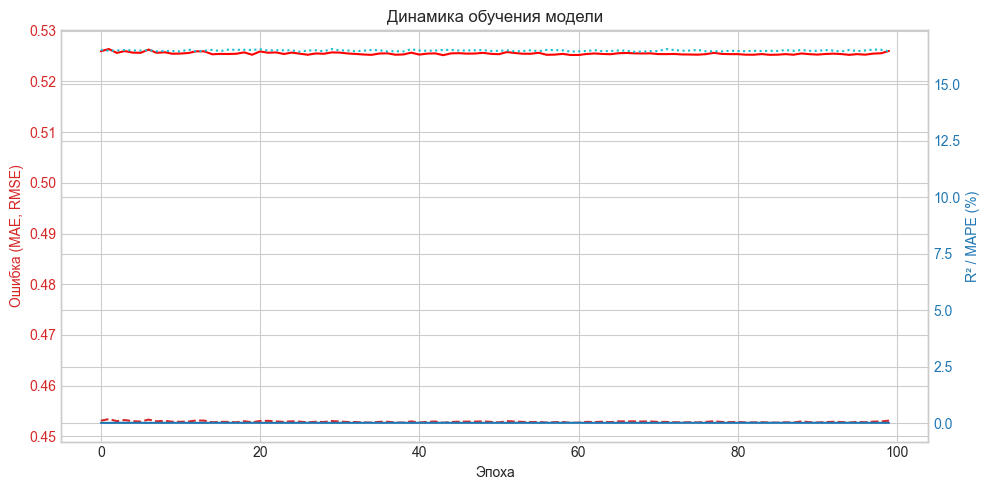

In [41]:
from sklearn.linear_model import SGDRegressor
import matplotlib.pyplot as plt

model = SGDRegressor()
history = {'MAE': [], 'RMSE': [], 'R2': [], 'MAPE': []}

epochs = 100
for epoch in range(epochs):
    model.partial_fit(X_train_scaled_3, y_train_3)

    y_pred = model.predict(X_train_scaled_3)
    metrics = evaluate_model(y_train_3, y_pred, split_name=f"Epoch {epoch}")
    
    # Сохраняем в историю
    for key in history:
        history[key].append(metrics[key])


# Рисуем графики (разделяем по смыслу)
fig, ax1 = plt.subplots(figsize=(10, 5))

# Левая ось для ошибок (MAE, RMSE)
ax1.set_xlabel('Эпоха')
ax1.set_ylabel('Ошибка (MAE, RMSE)', color='tab:red')
ax1.plot(history['MAE'],  color='tab:red', linestyle='--')
ax1.plot(history['RMSE'], color='red')
ax1.tick_params(axis='y', labelcolor='tab:red')

# Правая ось для процентов и коэффициентов (R2, MAPE)
ax2 = ax1.twinx() 
ax2.set_ylabel('R² / MAPE (%)', color='tab:blue')
ax2.plot(history['R2'], color='tab:blue')
ax2.plot(history['MAPE'], color='tab:cyan', linestyle=':')
ax2.tick_params(axis='y', labelcolor='tab:blue')

plt.title('Динамика обучения модели')
fig.tight_layout()
plt.show()

### Оценка с помощью более мощного инструмента

С помощью нейронки написан небольшой слот для обучения модели, чтобы понять, что проблема не в модели, а в данных - не хватает фичей связанных с жизнью студентов

Применение градиентного бустинга (CatBoost) позволило улучшить точность прогноза на 60% по сравнению с линейной моделью. Однако низкий коэффициент детерминации (R^2 = 0.078) указывает на то, что академическая успеваемость (CGPA) является многофакторным процессом, где поведенческие признаки (сон, физическая активность) играют второстепенную роль. Ключевым выявленным фактором влияния стало наличие депрессии.

In [26]:
from catboost import CatBoostRegressor

# Укажите названия колонок, которые являются текстовыми (категориальными)


cb_model = CatBoostRegressor(
    iterations=1000,
    depth=6,
    learning_rate=0.03,
    verbose=100 # выводить отчет каждые 100 деревьев
)

# Обучаем на исходных данных (без One-Hot Encoding!)
cb_model.fit(X_train_1, y_train_1) 

y_pred_cb = cb_model.predict(X_test_1)

evaluate_model(y_test_1, y_pred_cb, "CatBoost", "Test")

0:	learn: 0.5310814	total: 172ms	remaining: 2m 51s
100:	learn: 0.5190688	total: 1.62s	remaining: 14.4s
200:	learn: 0.5181999	total: 3.95s	remaining: 15.7s
300:	learn: 0.5175260	total: 4.42s	remaining: 10.3s
400:	learn: 0.5168151	total: 4.9s	remaining: 7.32s
500:	learn: 0.5160845	total: 5.34s	remaining: 5.32s
600:	learn: 0.5153308	total: 5.89s	remaining: 3.91s
700:	learn: 0.5145610	total: 6.38s	remaining: 2.72s
800:	learn: 0.5137618	total: 6.86s	remaining: 1.71s
900:	learn: 0.5130284	total: 7.26s	remaining: 798ms
999:	learn: 0.5123358	total: 7.65s	remaining: 0us

📊 Метрики для CatBoost на выборке Test:
  MAE:  0.45
  RMSE: 0.52
  R²:   0.0462
  MAPE: 16.40%


{'MAE': 0.4491485668979028,
 'RMSE': np.float64(0.5193968913329878),
 'R2': 0.04623139235562934,
 'MAPE': 16.404101527738764}

### Шаг 4 - готовим данные для логистической регресси

In [27]:
df_cleaned.head()

,Student_ID,Age,Male,Academic_score,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression,Department_Business,Department_Engineering,Department_Medical,Department_Science
0,1001,22,0,3.50,7.3,3.3,3.4,1.900000,5,0,0,0,0,1
1,1002,20,1,2.72,5.5,7.2,6.0,2.366667,2,0,0,1,0,0
2,1003,20,1,3.01,5.4,2.3,1.8,2.283333,3,0,0,0,1,0
3,1004,21,1,3.63,8.1,2.0,4.6,2.166667,3,0,0,1,0,0
4,1005,19,1,3.14,6.8,2.6,4.3,0.066667,6,0,0,0,0,0


In [28]:
data_logistic = df_cleaned.copy()
y_target_logistic = df_cleaned["Depression"]
data_logistic.drop(columns=["Student_ID","Depression"],inplace=True)
data_logistic.head()

,Age,Male,Academic_score,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Department_Business,Department_Engineering,Department_Medical,Department_Science
0,22,0,3.50,7.3,3.3,3.4,1.900000,5,0,0,0,1
1,20,1,2.72,5.5,7.2,6.0,2.366667,2,0,1,0,0
2,20,1,3.01,5.4,2.3,1.8,2.283333,3,0,0,1,0
3,21,1,3.63,8.1,2.0,4.6,2.166667,3,0,1,0,0
4,19,1,3.14,6.8,2.6,4.3,0.066667,6,0,0,0,0


### Шаг 5 - обучаем логистическую регрессию

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(data_logistic, y_target_logistic, test_size=0.2, random_state=42)
X_valid_log, X_test_log, y_valid_log, y_test_log = train_test_split(X_test_log, y_test_log, test_size=0.5, random_state=42)

scaler_log = StandardScaler()
X_train_scaled_log = scaler_log.fit_transform(X_train_log)
X_valid_scaled_log = scaler_log.transform(X_valid_log)
X_test_scaled_log = scaler_log.transform(X_test_log)

model_log = LogisticRegression(class_weight='balanced',max_iter=10_000)
model_log.fit(X_train_scaled_log, y_train_log)

y_pred_log = model_log.predict(X_train_scaled_log)
y_pred_valid_log = model_log.predict(X_valid_scaled_log)
y_pred_test_log = model_log.predict(X_test_scaled_log)

y_proba_train = model_log.predict_proba(X_train_scaled_log)[:, 1] # вероятность принадлежности объекта к положительному классу
y_proba_valid = model_log.predict_proba(X_valid_scaled_log)[:, 1]

y_proba_test = model_log.predict_proba(X_test_scaled_log)[:, 1]

def evaluate_classification(y_true, y_pred, y_proba=None, dataset_name="Dataset", split_name="Train"):
    """Расчет и вывод метрик классификации"""
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc_roc = roc_auc_score(y_true, y_proba) if y_proba is not None else None

    print(f"\n📊 Метрики для {dataset_name} на {split_name}:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    if auc_roc:
        print(f"  AUC-ROC:   {auc_roc:.4f}")

    return {'Accuracy': accuracy, 'Precision': precision, 'Recall': recall, 'F1': f1, 'AUC-ROC': auc_roc}

print(evaluate_classification(y_train_log,y_pred_log, y_proba=y_proba_train, dataset_name="Dataset", split_name="Train"))
print(evaluate_classification(y_valid_log,y_pred_valid_log, y_proba=y_proba_valid, dataset_name="Dataset", split_name="Validation"))
print(evaluate_classification(y_test_log,y_pred_test_log, y_proba=y_proba_test, dataset_name="Dataset", split_name="Test"))
print(model_log.coef_.tolist()[0])


📊 Метрики для Dataset на Train:
  Accuracy:  0.6233
  Precision: 0.1669
  Recall:    0.6844
  F1-Score:  0.2683
  AUC-ROC:   0.6852
{'Accuracy': 0.6232839720160267, 'Precision': 0.16688412173438116, 'Recall': 0.6844201095072175, 'F1': 0.26833849681652966, 'AUC-ROC': 0.6852009710233067}

📊 Метрики для Dataset на Validation:
  Accuracy:  0.6220
  Precision: 0.1674
  Recall:    0.6943
  F1-Score:  0.2698
  AUC-ROC:   0.6925
{'Accuracy': 0.6219855305466238, 'Precision': 0.16742953505179475, 'Recall': 0.6943056943056943, 'F1': 0.26979813664596275, 'AUC-ROC': 0.6925253274264558}

📊 Метрики для Dataset на Test:
  Accuracy:  0.6160
  Precision: 0.1626
  Recall:    0.6882
  F1-Score:  0.2630
  AUC-ROC:   0.6857
{'Accuracy': 0.6159951773334673, 'Precision': 0.1625744934445769, 'Recall': 0.6881937436932392, 'F1': 0.2630158118010027, 'AUC-ROC': 0.6857322913586709}
[-0.02216998322368105, 0.014742385246565617, -0.5926949454424484, -0.11524764190140316, 0.0022566585353043303, -0.002091470061988009, 

### График learning curve (умнеет ли модель)

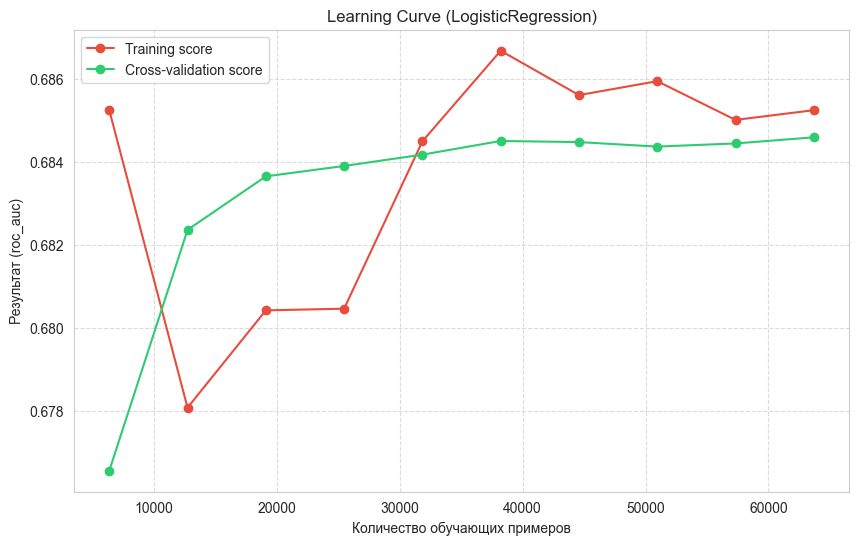

In [30]:
from sklearn.model_selection import learning_curve
import numpy as np
def plot_learning_curve(model,X,y,scoring="roc_auc"):
    train_sizes = np.linspace(0.1,1.0,10)

    train_sizes, train_scores, test_scores = learning_curve(
        model, X, y, cv=5, scoring=scoring, n_jobs=-1, 
        train_sizes=train_sizes, random_state=42
    )
    train_mean = np.mean(train_scores,axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)

    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, train_mean, 'o-', color="#e74c3c", label="Training score")

    plt.plot(train_sizes, test_mean, 'o-', color="#2ecc71", label="Cross-validation score")

    plt.title(f"Learning Curve ({type(model).__name__})")
    plt.xlabel("Количество обучающих примеров")
    plt.ylabel(f"Результат ({scoring})")
    plt.legend(loc="best")
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()



plot_learning_curve(model_log, X_train_scaled_log, y_train_log, scoring='roc_auc')


📊 Метрики для Dataset на Test:
  Accuracy:  0.6160
  Precision: 0.1626
  Recall:    0.6882
  F1-Score:  0.2630
  AUC-ROC:   0.6857

📊 Метрики для Dataset на Train:
  Accuracy:  0.6233
  Precision: 0.1669
  Recall:    0.6844
  F1-Score:  0.2683
  AUC-ROC:   0.6852


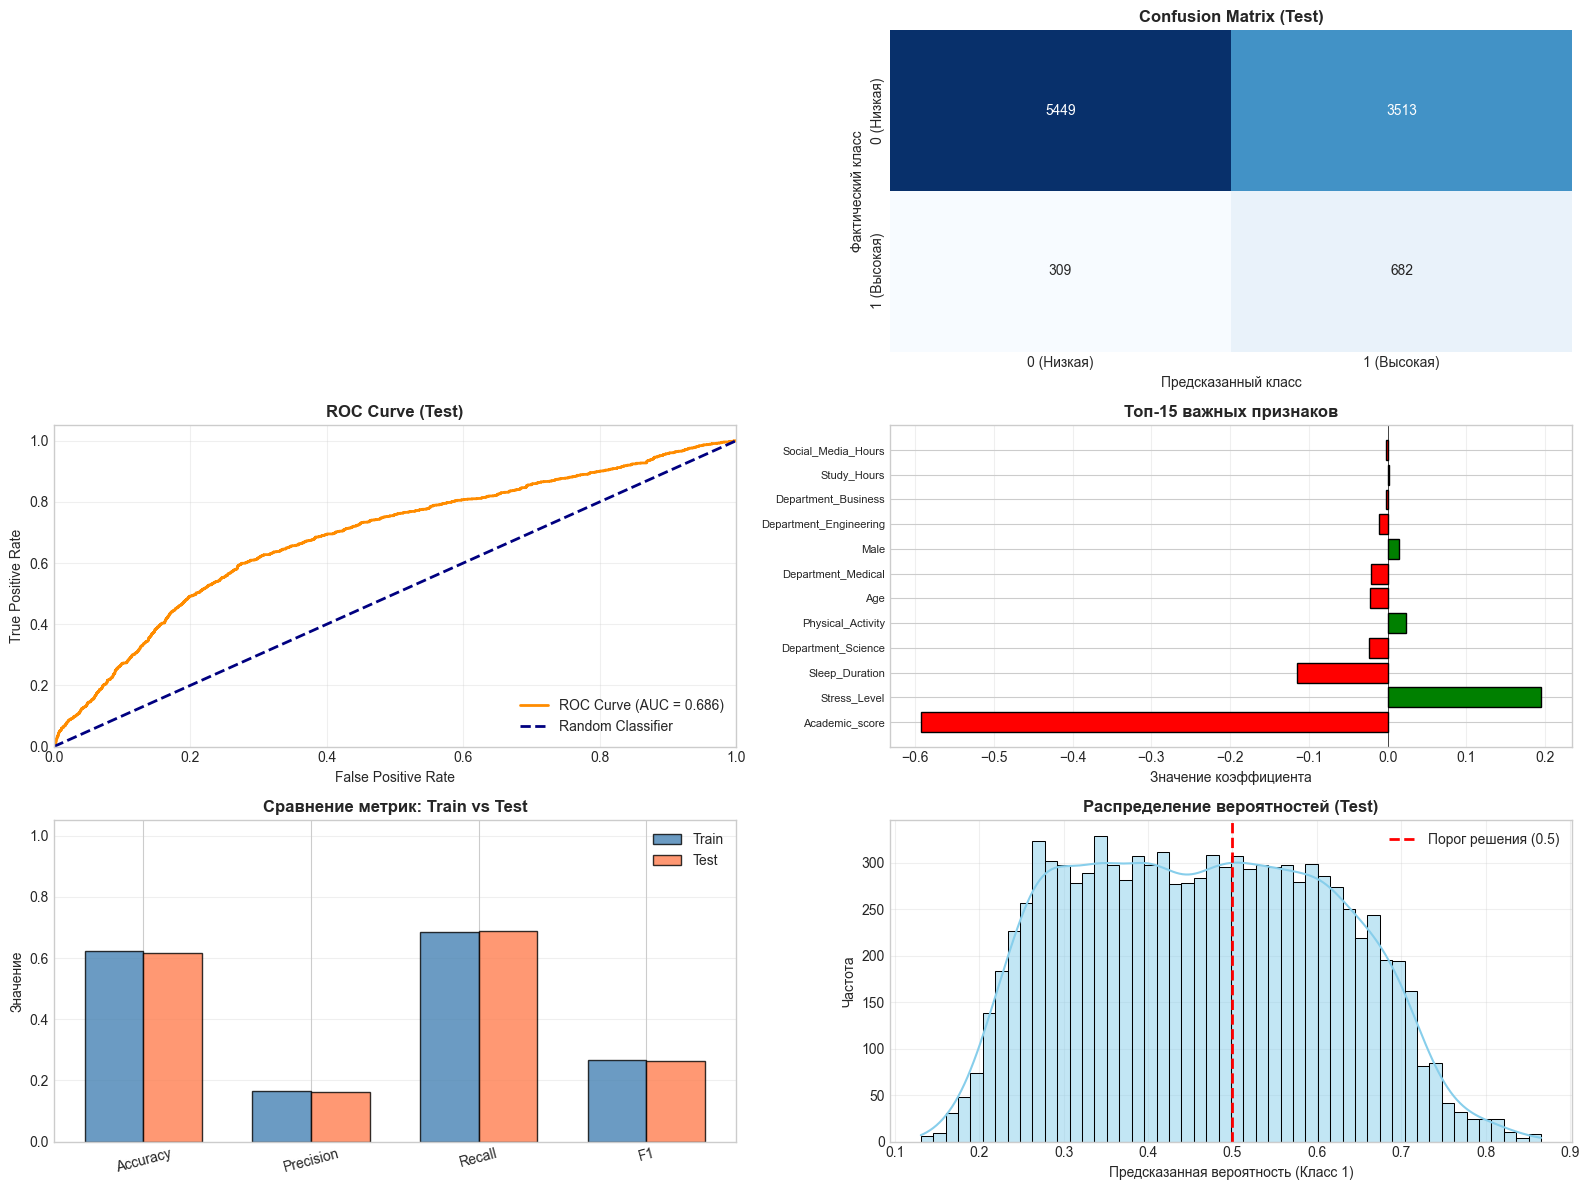

In [31]:
from sklearn.metrics import confusion_matrix, roc_curve
plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(16, 12))

# --- 5.2 Confusion Matrix (Test) ---
ax2 = plt.subplot(3, 2, 2)
cm = confusion_matrix(y_test_log, y_pred_test_log)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax2, cbar=False)
ax2.set_xlabel('Предсказанный класс', fontsize=10)
ax2.set_ylabel('Фактический класс', fontsize=10)
ax2.set_title('Confusion Matrix (Test)', fontsize=12, fontweight='bold')
ax2.set_xticklabels(['0 (Низкая)', '1 (Высокая)'])
ax2.set_yticklabels(['0 (Низкая)', '1 (Высокая)'])

# --- 5.3 ROC Curve ---
test_metrics = evaluate_classification(y_test_log,y_pred_test_log, y_proba=y_proba_test, dataset_name="Dataset", split_name="Test")
ax3 = plt.subplot(3, 2, 3)
fpr, tpr, thresholds = roc_curve(y_test_log, y_proba_test)
ax3.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {test_metrics["AUC-ROC"]:.3f})')
ax3.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
ax3.set_xlim([0.0, 1.0])
ax3.set_ylim([0.0, 1.05])
ax3.set_xlabel('False Positive Rate', fontsize=10)
ax3.set_ylabel('True Positive Rate', fontsize=10)
ax3.set_title('ROC Curve (Test)', fontsize=12, fontweight='bold')
ax3.legend(loc="lower right")
ax3.grid(True, alpha=0.3)

# --- 5.4 Распределение весов модели (Топ-15) ---
ax4 = plt.subplot(3, 2, 4)
weights_df = pd.DataFrame({
    'feature': X_train_log.columns,
    'weight': model_log.coef_.tolist()[0]
})
weights_df = weights_df.sort_values(by='weight', key=lambda x: np.abs(x), ascending=False).head(15)

colors = ['green' if w > 0 else 'red' for w in weights_df['weight']]
bars = ax4.barh(weights_df['feature'], weights_df['weight'], color=colors, edgecolor='black')
ax4.set_xlabel('Значение коэффициента', fontsize=10)
ax4.set_title('Топ-15 важных признаков', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='x')
ax4.axvline(x=0, color='black', lw=0.5)
plt.setp(ax4.get_yticklabels(), fontsize=8)

# --- 5.5 Сравнение метрик Train/Test ---
train_metrics = evaluate_classification(y_train_log,y_pred_log, y_proba=y_proba_train, dataset_name="Dataset", split_name="Train")
ax5 = plt.subplot(3, 2, 5)
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1']
x_pos = np.arange(len(metrics_names))
width = 0.35

train_vals = [train_metrics['Accuracy'], train_metrics['Precision'], train_metrics['Recall'], train_metrics['F1']]
test_vals = [test_metrics['Accuracy'], test_metrics['Precision'], test_metrics['Recall'], test_metrics['F1']]

ax5.bar(x_pos - width/2, train_vals, width, label='Train', alpha=0.8, edgecolor='black', color='steelblue')
ax5.bar(x_pos + width/2, test_vals, width, label='Test', alpha=0.8, edgecolor='black', color='coral')
ax5.set_xticks(x_pos)
ax5.set_xticklabels(metrics_names, rotation=15)
ax5.set_ylabel('Значение', fontsize=10)
ax5.set_title('Сравнение метрик: Train vs Test', fontsize=12, fontweight='bold')
ax5.set_ylim(0, 1.05)
ax5.legend()
ax5.grid(True, alpha=0.3, axis='y')

# --- 5.6 Распределение предсказанных вероятностей ---
ax6 = plt.subplot(3, 2, 6)
sns.histplot(y_proba_test, bins=50, kde=True, ax=ax6, color='skyblue', edgecolor='black')
ax6.axvline(x=0.5, color='red', linestyle='--', lw=2, label='Порог решения (0.5)')
ax6.set_xlabel('Предсказанная вероятность (Класс 1)', fontsize=10)
ax6.set_ylabel('Частота', fontsize=10)
ax6.set_title('Распределение вероятностей (Test)', fontsize=12, fontweight='bold')
ax6.legend()
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('logistic_regression_results.png', dpi=300, bbox_inches='tight')
plt.show()

### Самоанализ:

In [32]:
my_data = {"Stress_Level":3,"Sleep_Duration":8.3,"Study_Hours":7,"Social_Media_Hours":4,"Physical_Activity":5}

my_data = pd.DataFrame(my_data, index=[0])
print("Предсказание среднего балла: ", model_2.predict(my_data))

my_data = {'Age':18, 'Male':1, 'Academic_score':3.001, 'Sleep_Duration':8.3, 'Study_Hours':7,
       'Social_Media_Hours':4, 'Physical_Activity':5, 'Stress_Level':3,
       'Department_Business':0, 'Department_Engineering':1, 'Department_Medical':0,
       'Department_Science':0}
my_data = pd.DataFrame(my_data,index=[0])
print("Предсказание депресии: ", model_log.predict(my_data))

Предсказание среднего балла:  [3.00198037]
Предсказание депресии:  [0]


c:\Users\Huawei\python_programming\Data_analysis_labs\Lab1\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
c:\Users\Huawei\python_programming\Data_analysis_labs\Lab1\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


### Немного экспериметов:


#### Удалим 70% строк с отсутствием депрессии и обучим модель на этих данных

In [33]:
df = df_cleaned.copy()

df_no = df[df['Depression'] == 0]
df_yes = df[df['Depression'] == 1]

df_no_sampled = df_no.sample(frac=0.3, random_state=42)

df_balanced = pd.concat([df_no_sampled, df_yes])

df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Новый размер выборки: {len(df_balanced)}")
print(df_balanced['Depression'].value_counts())

Новый размер выборки: 36876
Depression
0    26848
1    10028
Name: count, dtype: int64


In [34]:
y_target = df_balanced["Depression"]
df_balanced.drop(columns=["Student_ID","Depression"],inplace=True)
df_balanced.head()

,Age,Male,Academic_score,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Department_Business,Department_Engineering,Department_Medical,Department_Science
0,23,0,2.72,6.7,5.3,5.8,1.333333,5,0,0,0,0
1,24,1,2.74,8.0,3.1,3.9,0.266667,4,0,0,0,0
2,18,0,4.00,6.8,7.7,4.8,1.416667,3,0,0,1,0
3,19,0,3.69,7.0,6.2,2.1,1.866667,4,0,0,1,0
4,23,0,3.11,5.8,4.1,3.0,0.500000,4,0,0,0,1


In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(df_balanced, y_target, test_size=0.2, random_state=42)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(class_weight="balanced")
model.fit(X_train_scaled, y_train)

y_pred_train = model.predict(X_train_scaled)
y_pred_test = model.predict(X_test_scaled)

y_proba_train = model.predict_proba(X_train_scaled)[:, 1] # вероятность принадлежности объекта к положительному классу
y_proba_test = model.predict_proba(X_test_scaled)[:, 1]

def evaluate_classification(y_true, y_pred, y_proba=None, dataset_name="Dataset", split_name="Train"):
    """Расчет и вывод метрик классификации"""
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc_roc = roc_auc_score(y_true, y_proba) if y_proba is not None else None

    print(f"\n📊 Метрики для {dataset_name} на {split_name}:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    if auc_roc:
        print(f"  AUC-ROC:   {auc_roc:.4f}")

    return {'Accuracy': accuracy, 'Precision': precision, 'Recall': recall, 'F1': f1, 'AUC-ROC': auc_roc}

evaluate_classification(y_train,y_pred_train)
evaluate_classification(y_test,y_pred_test)
evaluate_classification(y_train_log,y_pred_log,split_name="Large train")


📊 Метрики для Dataset на Train:
  Accuracy:  0.6380
  Precision: 0.4032
  Recall:    0.6858
  F1-Score:  0.5079

📊 Метрики для Dataset на Train:
  Accuracy:  0.6395
  Precision: 0.4019
  Recall:    0.6836
  F1-Score:  0.5062

📊 Метрики для Dataset на Large train:
  Accuracy:  0.6233
  Precision: 0.1669
  Recall:    0.6844
  F1-Score:  0.2683


{'Accuracy': 0.6232839720160267,
 'Precision': 0.16688412173438116,
 'Recall': 0.6844201095072175,
 'F1': 0.26833849681652966,
 'AUC-ROC': None}